In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = Path("../data/PathMNIST/pathmnist_224.npz")

# PathMNIST (MedMNIST) class names
CLASS_NAMES = (
    "adipose",
    "background",
    "debris",
    "lymphocytes",
    "mucus",
    "smooth muscle",
    "normal colon mucosa",
    "cancer-associated stroma",
    "colorectal adenocarcinoma epithelium",
)

# mmap_mode='r' avoids loading the full ~12GB archive into RAM
data = np.load(DATA_PATH, mmap_mode="r")

train_images, train_labels = data["train_images"], data["train_labels"]
val_images, val_labels = data["val_images"], data["val_labels"]
test_images, test_labels = data["test_images"], data["test_labels"]

for split, images, labels in [
    ("train", train_images, train_labels),
    ("val", val_images, val_labels),
    ("test", test_images, test_labels),
]:
    print(f"{split:5s}  images={images.shape}  labels={labels.shape}  dtype={images.dtype}")

print(f"\nnum classes: {len(CLASS_NAMES)}")
print(f"label range: [{int(train_labels.min())}, {int(train_labels.max())}]")

train  images=(89996, 224, 224, 3)  labels=(89996, 1)  dtype=uint8
val    images=(10004, 224, 224, 3)  labels=(10004, 1)  dtype=uint8
test   images=(7180, 224, 224, 3)  labels=(7180, 1)  dtype=uint8

num classes: 9
label range: [0, 8]


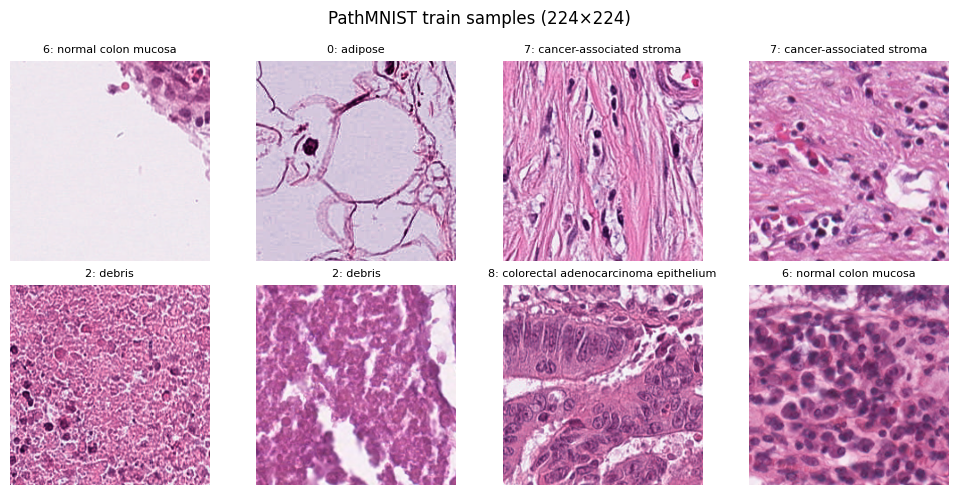

In [2]:
# Quick visual sanity check
rng = np.random.default_rng(0)
idxs = rng.choice(len(train_images), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, i in zip(axes.flat, idxs):
    label = int(train_labels[i].item())
    ax.imshow(train_images[i])
    ax.set_title(f"{label}: {CLASS_NAMES[label]}", fontsize=8)
    ax.axis("off")
fig.suptitle("PathMNIST train samples (224×224)")
plt.tight_layout()
plt.show()


In [5]:
import pickle
import os
import urllib

import numpy as np
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm

In [14]:
REPO_DIR = '/common/ganesanv/tlab/opt/dinov3'


In [15]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

# we take DINOv3 ViT-L
MODEL_NAME = MODEL_DINOV3_VITB
WEIGHTS_PATH = '/common/ganesanv/tlab/opt/dinov3-weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'

model = torch.hub.load(
    REPO_DIR,
    model=MODEL_NAME,
    source="local",
    weights=WEIGHTS_PATH,
)
model.cuda()

13.7%

Downloading: "file:///common/ganesanv/tlab/opt/dinov3-weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth" to /home/ganesanv/.cache/torch/hub/checkpoints/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth


100.0%


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    

In [17]:
MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

In [86]:
import torch.nn as nn
class LinearProbe(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.model = model
        self.linear = nn.Sequential(
            nn.Linear(in_features, out_features), 
            nn.Softmax(dim=-1)
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
    def forward(self, x):
        with torch.no_grad():
            with torch.autocast(device_type='cuda', dtype=torch.float32):
                output = model.forward_features(x)

        patch_tokens = output['x_norm_patchtokens']

        reshaped = patch_tokens.reshape(patch_tokens.shape[0], patch_tokens.shape[-1], patch_tokens.shape[1])

        pooled = self.pool(reshaped).view(patch_tokens.shape[0], -1)
        
        ret = self.linear(pooled)
        return ret

In [78]:
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

PATCH_SIZE = 16
IMAGE_SIZE = 224
EMBED_DIM = 768
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

class PathMNIST(Dataset):
    def __init__(self, images, labels, image_size: int = IMAGE_SIZE, patch_size: int = PATCH_SIZE):
        self.images = images
        self.labels = labels
        self.image_size = image_size
        self.patch_size = patch_size

    def __len__(self):
        return len(self.images)

    
    def resize_transform(self, image: Image, image_size: int = IMAGE_SIZE, patch_size: int = PATCH_SIZE):
        w, h = image.size
        h_patches = int(image_size / patch_size)
        w_patches = int((w * image_size) / (h * patch_size))
        return TF.to_tensor(TF.resize(image, (h_patches * patch_size, w_patches * patch_size)))

        

    def __getitem__(self, idx):
        image = self.images[idx]
        image_resized = self.resize_transform(Image.fromarray(image).convert('RGB'))
        image_resized_norm = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
        label = torch.tensor(self.labels[idx], dtype=torch.long).squeeze()
        return image_resized_norm, label

train_dataset = PathMNIST(train_images, train_labels)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

val_dataset = PathMNIST(val_images, val_labels)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)




In [89]:
labels, counts = np.unique(train_labels, return_counts=True)
labels, counts2 = np.unique(val_labels, return_counts=True)

weights = torch.tensor([(counts2[i] + counts[i]) / (len(train_labels)+len(val_labels)) for i in range(len(counts))], dtype=torch.float32)
weights=weights.cuda()

In [91]:
probe = LinearProbe(EMBED_DIM, len(CLASS_NAMES))
probe.cuda()
criterion = nn.CrossEntropyLoss(weight=weights)
optim = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
        data, target = data.cuda(), target.cuda()
        output = probe(data)
        loss = criterion(output, target)
        loss.backward()
        optim.step()

    print(f"Epoch {epoch} loss: {loss.item()}")
    correct = 0
    total= 0
    for batch_idx, (data, target) in tqdm(enumerate(val_loader), total=len(val_loader)):
        data, target = data.cuda(), target.cuda()
        output = probe(data)
        loss = criterion(output, target)
        correct += (output.argmax(dim=1) == target).sum().item()
        total += target.size(0)
    print(f"Epoch {epoch} accuracy: {correct / total}")
        


  0%|▏                                                                                                                        | 1/704 [00:00<01:14,  9.38it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [08:30<00:00,  1.38it/s]


Epoch 0 loss: 2.1966817378997803


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [01:03<00:00,  1.25it/s]


Epoch 0 accuracy: 0.17502998800479808


...

Epoch 8 accuracy: 0.17572970811675329


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [08:27<00:00,  1.39it/s]


Epoch 9 loss: 2.1991302967071533


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [01:01<00:00,  1.28it/s]

Epoch 9 accuracy: 0.17443022790883647
